In [1]:
# Cell 1 — Title & imports
# 19 June | Topic: SVM with sklearn — full pipeline
# SVC for classification, scaling, grid search, real datasets

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import load_iris, load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

In [2]:
# Cell 2 — Version 1: Iris dataset — SVM with scaling
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ALWAYS scale before SVM — it is sensitive to feature magnitude
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', C=1, gamma='scale', random_state=42))
])
pipe.fit(X_train, y_train)

print(f"Test Accuracy: {accuracy_score(y_test, pipe.predict(X_test))*100:.1f}%")
print()
print(classification_report(y_test, pipe.predict(X_test),
                             target_names=iris.target_names))

Test Accuracy: 100.0%

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



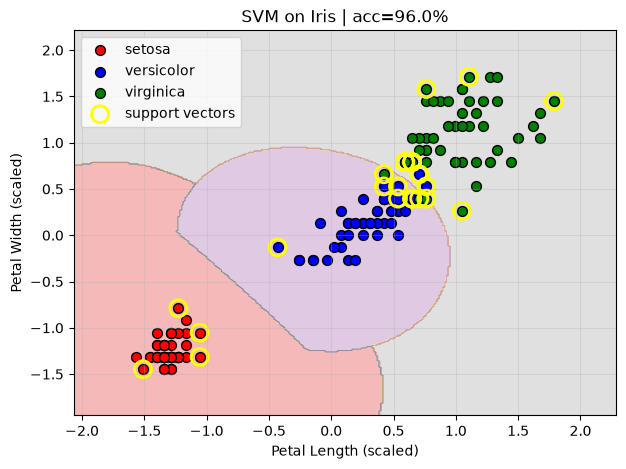

In [3]:
# Cell 3 — Version 2: decision boundary on 2 features
X2 = iris.data[:, [2, 3]]   # petal length + petal width only
y2 = iris.target

scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)

model = SVC(kernel='rbf', C=10, gamma='scale')
model.fit(X2_scaled, y2)

xx, yy = np.meshgrid(np.linspace(X2_scaled[:,0].min()-0.5,
                                  X2_scaled[:,0].max()+0.5, 300),
                     np.linspace(X2_scaled[:,1].min()-0.5,
                                  X2_scaled[:,1].max()+0.5, 300))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
colors = ['red','blue','green']
for cls, col, name in zip([0,1,2], colors, iris.target_names):
    mask = y2 == cls
    plt.scatter(X2_scaled[mask,0], X2_scaled[mask,1],
                c=col, label=name, edgecolors='k', s=50)
plt.scatter(model.support_vectors_[:,0], model.support_vectors_[:,1],
            s=150, facecolors='none', edgecolors='yellow', linewidths=2,
            label='support vectors')
plt.xlabel('Petal Length (scaled)'); plt.ylabel('Petal Width (scaled)')
plt.title(f'SVM on Iris | acc={accuracy_score(y2, model.predict(X2_scaled))*100:.1f}%')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

In [4]:
# Cell 4 — Version 3: GridSearchCV — find best C and gamma
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipe = Pipeline([('scaler', StandardScaler()), ('svm', SVC(random_state=42))])

param_grid = {
    'svm__C':      [0.1, 1, 10, 100],
    'svm__gamma':  ['scale', 'auto', 0.001, 0.01],
    'svm__kernel': ['rbf', 'linear']
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)

print(f"Best params:    {grid.best_params_}")
print(f"Best CV acc:    {grid.best_score_*100:.1f}%")
print(f"Test accuracy:  {accuracy_score(y_test, grid.predict(X_test))*100:.1f}%")

Best params:    {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Best CV acc:    97.4%
Test accuracy:  98.2%


              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        43
      benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



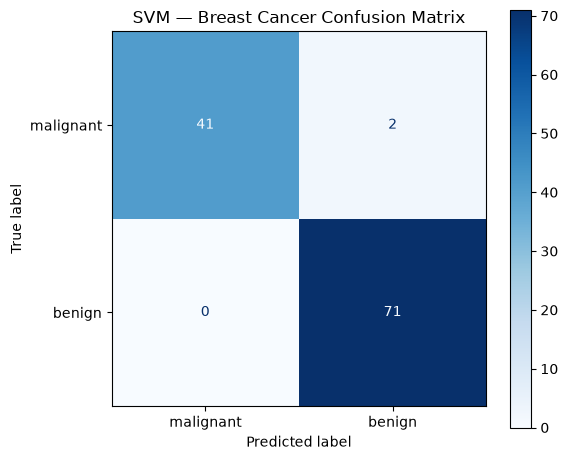


Support vectors per class: [25 28]
Total support vectors:     53


In [5]:
# Cell 5 — Version 4: confusion matrix + full report on breast cancer
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred,
      target_names=load_breast_cancer().target_names))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=load_breast_cancer().target_names,
    cmap='Blues', ax=ax)
ax.set_title('SVM — Breast Cancer Confusion Matrix')
plt.tight_layout(); plt.show()

n_sv = best_model.named_steps['svm'].n_support_
print(f"\nSupport vectors per class: {n_sv}")
print(f"Total support vectors:     {n_sv.sum()}")